In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, NNConv, CGConv, global_max_pool, GCNConv, GATConv, GATv2Conv

from pymatgen.core import Structure, PeriodicSite, DummySpecie, Composition, Element
from pymatgen.core.periodic_table import Element as PMGElement
from pymatgen.analysis.local_env import MinimumDistanceNN, CrystalNN, VoronoiNN
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

# import json
import graphy_gnn

/home/amutua/inverse/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Prep

In [2]:
if not os.path.exists(f"Final_Dataset/gnn models/train_graphs.pt"):
    comb_df = pd.read_csv("Final_Dataset/combined/combined_data.csv")

    comb_df = comb_df[comb_df["defect_sites"] != 1]
    
    # Split the data
    train_set, test_set = train_test_split(comb_df, test_size=0.2, stratify=comb_df['strata'], random_state=42)
    test_set, val_set = train_test_split(test_set, test_size=0.5, random_state=42)

    # Create graphs for each set
    train_graphs = graphy_gnn.fast_grapy(train_set)
    val_graphs = graphy_gnn.fast_grapy(val_set)
    test_graphs = graphy_gnn.fast_grapy(test_set)

    # Save graphs
    torch.save(train_graphs, "Final_Dataset/gnn models/train_graphs.pt")
    torch.save(val_graphs, "Final_Dataset/gnn models/val_graphs.pt")
    torch.save(test_graphs, "Final_Dataset/gnn models/test_graphs.pt")

else:
    train_graphs = torch.load("Final_Dataset/gnn models/train_graphs.pt", weights_only=False)
    val_graphs = torch.load("Final_Dataset/gnn models/val_graphs.pt", weights_only=False)
    test_graphs = torch.load("Final_Dataset/gnn models/test_graphs.pt", weights_only=False)

In [3]:
# Find the graph where the edge features has shape 0 and remove them

def remove_1_defect_graphs(graphs):
    unwanted = []
    for i, data in enumerate(graphs):
        if data.edge_attr.shape[0] == 0:
            unwanted.append(i)

    new_graphs = [data for i, data in enumerate(graphs) if i not in unwanted]
    return new_graphs

new_train_graphs = remove_1_defect_graphs(train_graphs)
new_val_graphs = remove_1_defect_graphs(val_graphs)
new_test_graphs = remove_1_defect_graphs(test_graphs)

Before Sampling
Counts per bin: [ 458 2634 1472 1168  274  318  232  275 1778  635 1294   18   33    9
 1274    4    1    3    2    4]
Bin boundaries: [0.0092     0.1358875  0.26257499 0.38926249 0.51594998 0.64263748
 0.76932497 0.89601247 1.02269997 1.14938746 1.27607496 1.40276245
 1.52944995 1.65613744 1.78282494 1.90951244 2.03619993 2.16288743
 2.28957492 2.41626242 2.54294991]


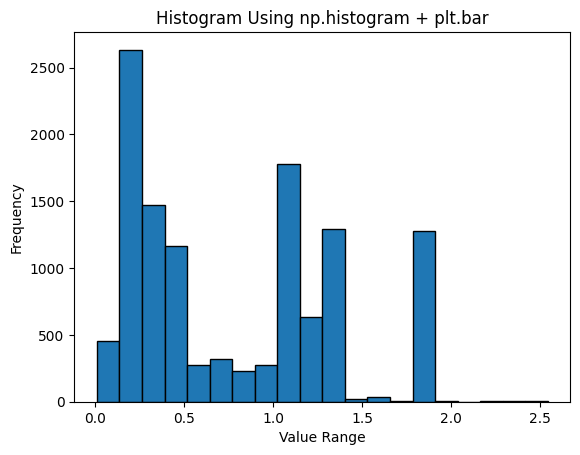

In [4]:
# Sample_train_graphs

print("Before Sampling")

train_targets = [new_train_graphs[i].y.item() for i in range(len(new_train_graphs))]

hist, bin_edges = np.histogram(train_targets, bins=20)

# frequency per bin
freq = hist + 1e-6

# inverse frequency weights
bin_weights = 1.0 / freq


print("Counts per bin:", hist)
print("Bin boundaries:", bin_edges)

# 2. Graphically plot the computed data
plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), edgecolor="black", align="edge")
plt.title("Histogram Using np.histogram + plt.bar")
plt.xlabel("Value Range")
plt.ylabel("Frequency")
plt.show()

After Sampling


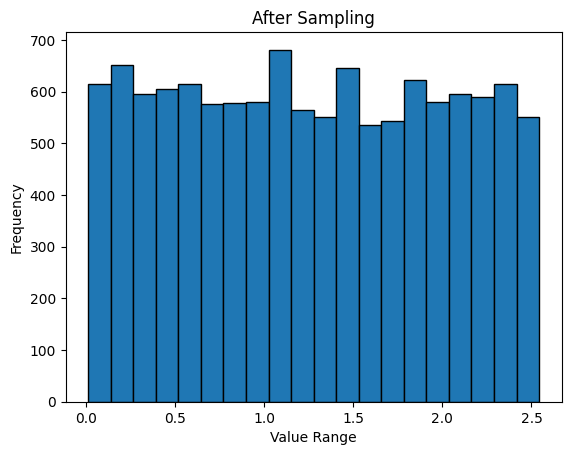

In [5]:
# Map each sample to a weight

bin_idx = np.digitize(train_targets, bin_edges[:-1])

sample_weights1 = bin_weights[bin_idx - 1]

from torch.utils.data import WeightedRandomSampler

sampler1 = WeightedRandomSampler(
    sample_weights1,
    len(sample_weights1),
    replacement=True
)

# Create data loaders
train_loader = DataLoader(new_train_graphs, batch_size=1, sampler=sampler1)
val_loader = DataLoader(new_val_graphs, batch_size=1, shuffle=False)
test_loader = DataLoader(new_test_graphs, batch_size=1, shuffle=False)

print("After Sampling")

new_targets1 = [i.y.item() for i in train_loader]

hist1, bin_edges1 = np.histogram(new_targets1, bins=20)

plt.bar(bin_edges1[:-1], hist1, width=np.diff(bin_edges1), edgecolor="black", align="edge")
plt.title("After Sampling")
plt.xlabel("Value Range")
plt.ylabel("Frequency")
plt.show()

In [6]:
# Use data size to determine model architecture
NODE_DIM =train_graphs[0].x.shape[1] # 27
EDGE_DIM =train_graphs[0].edge_attr.shape[1] # 14
HIDDEN_DIM = 128
EMBED_DIM = 64
U_DIM =train_graphs[0].u.shape[1] # 14

# The GNN Model

In [ ]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def evaluate(model, loader, loss_fn, device):
    model.eval()
    eval_loss = 0
    with torch.no_grad():
        for data in loader:

            data = data.to(device)

            out = model(data)
            loss = loss_fn(out, data.y)

            eval_loss += loss.item() * data.num_graphs
    return eval_loss / len(loader.dataset)

def train(model, train_loader, loss_fn, device, optimizer):
    model.train()
    train_loss = 0

    for data in train_loader:
        optimizer.zero_grad()

        data = data.to(device)
        out = model(data)
        loss = loss_fn(out, data.y)

        loss.backward()

        optimizer.step()
        train_loss += loss.item() * data.num_graphs

    return train_loss / len(train_loader.dataset)

def predict(model, loader, device, visualize=False):
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)

            if data.y:
                actuals.append(data.y.cpu().numpy())

            predictions.append(out.cpu().numpy())

    prediction = np.concatenate(predictions, axis=0).flatten()
    actual = np.concatenate(actuals, axis=0).flatten()

    if visualize:
        fig, axs = plt.subplots(3, 1, figsize=(10, 15))

        # model values
        predicted_values = prediction
        actual_values = actual
        residuals = actual_values - predicted_values


        axs[0].scatter(actual_values, predicted_values )
        axs[0].plot(actual_values, actual_values, c="black")
        axs[0].set_xlabel('Actual Band Gaps(eV)')
        axs[0].set_ylabel('Predicted Band Gaps(eV)')
        axs[0].set_title('Actual vs Predicted Band Gap Values')
        axs[0].legend()

        axs[1].plot(actual_values[100:150], label='Actual Values', marker='o')
        axs[1].plot(predicted_values[100:150], label='Predicted Values', marker='o')
        axs[1].set_xlabel('Samples')
        axs[1].set_ylabel('Band gap(eV)')
        axs[1].set_title('Actual vs Predicted Band Gap Values')
        axs[1].legend()

        axs[2].scatter(predicted_values, residuals )
        axs[2].axhline(0, color='red', linestyle='--')
        axs[2].set_xlabel('Predicted Band Gaps(eV)')
        axs[2].set_ylabel('Residuals (Actual - Predicted)')
        axs[2].set_title('Residual Plot')

        plt.tight_layout()
        plt.show()

    return prediction, actual

In [ ]:
# Loss functions

class LogCoshLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, input, target):
        ey_t = input-target
        return torch.mean(torch.log(torch.cosh(ey_t + 1e-12)))


class RelativeMSELoss(nn.Module):
    def __inti__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        return torch.mean(((y_pred-y_true)/ (y_true + 1e-8)) ** 2)


class SMAPELoss(nn.Module):
    def __inti__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        numerator = torch.abs(y_pred - y_true)
        denominator = (torch.abs(y_true) + torch.abs(y_pred))/2.0 + 1e-8
        return torch.mean(numerator/denominator)

class RelativeWeightedLoss(nn.Module):
    def __init__(self, delta=0.1, lambda_rel=0.3, eps=1e-2, alpha=1.5):
        super().__init__()
        self.delta = delta
        self.lambda_rel = lambda_rel  # weight of relative term
        self.eps = eps                # prevents div-by-zero for ~0 targets
        self.alpha = alpha

    def forward(self, input, target):
        error = input - target
        abs_error = torch.abs(error)

        # Huber absolute loss
        huber = torch.where(
            abs_error < self.delta,
            0.5 * error ** 2,
            self.delta * (abs_error - 0.5 * self.delta)
        )

        # Relative error: penalizes proportional misses
        relative = abs_error / (torch.abs(target) + self.eps)
        to_return = torch.mean(huber + self.lambda_rel * relative)

        # weights = (1.0 + target) ** self.alpha
        # weighted = weights * huber 
        # to_return = torch.mean(weighted)

        return to_return

# loss_fn = nn.MSELoss()
# loss_fn = LogCoshLoss()
# loss_fn = RelativeWeightedLoss()
# loss_fn = RelativeMSELoss()
# loss_fn = SMAPELoss()

In [ ]:
# Train model
'''

def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            loss = loss_fn(out, data.y)

            total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

def train(model, train_loader, val_loader, epochs, optimizer, loss_fn):
    train_losses = []
    val_losses = []

    # Learning rate scheduler to help convergence
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

    for epoch in range(1, epochs+1):
        model.train()
        total_loss = 0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()

            out = model(data)
            loss = loss_fn(out, data.y)

            loss.backward()
            optimizer.step()
            total_loss += loss.item() * data.num_graphs
        train_loss = total_loss / len(train_loader.dataset)
        # train_loss = train(the_model, train_loader, optimizer, loss_fn)
        val_loss = evaluate(model, val_loader, loss_fn)
        scheduler.step()

        print(f'Epoch {epoch:03d}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

        train_losses.append(train_loss)
        val_losses.append(val_loss)

    # Test model
    test_loss = evaluate(model, test_loader, loss_fn)
    print(f'Test Loss: {test_loss:.4f}')

    return train_losses, val_losses

def predict(model, loader, actuals=False):
    model.eval()
    if actuals:
        predictions = []
        actual = []
        with torch.no_grad():
            for data in loader:
                data = data.to(device)

                out = model(data)
                predictions.append(out.cpu().numpy())
                actual.append(data.y.cpu().numpy())

        predictions = np.concatenate(predictions, axis=0).flatten()
        actual = np.concatenate(actual, axis=0).flatten()
        return predictions, actual
    else:
        predictions = []
        with torch.no_grad():
            for data in loader:
                data = data.to(device)

                out = model(data)
                predictions.append(out.cpu().numpy())

        predictions = np.concatenate(predictions, axis=0).flatten()
        return predictions

# Informative Graphs
def get_graphs(train_losses, val_losses, the_model):
    fig, axs = plt.subplots(3, 1, figsize=(10, 15))

    # model values
    predicted_values, actual_values = predict(the_model, test_loader, actuals=True)
    residuals = actual_values - predicted_values


    axs[0].scatter(actual_values, predicted_values )
    axs[0].plot(actual_values, actual_values, c="black")
    axs[0].set_xlabel('Actual Band Gaps(eV)')
    axs[0].set_ylabel('Predicted Band Gaps(eV)')
    axs[0].set_title('Actual vs Predicted Band Gap Values')
    axs[0].legend()

    axs[1].plot(actual_values[100:150], label='Actual Values', marker='o')
    axs[1].plot(predicted_values[100:150], label='Predicted Values', marker='o')
    axs[1].set_xlabel('Samples')
    axs[1].set_ylabel('Band gap(eV)')
    axs[1].set_title('Actual vs Predicted Band Gap Values')
    axs[1].legend()

    axs[2].scatter(predicted_values, residuals )
    axs[2].axhline(0, color='red', linestyle='--')
    axs[2].set_xlabel('Predicted Band Gaps(eV)')
    axs[2].set_ylabel('Residuals (Actual - Predicted)')
    axs[2].set_title('Residual Plot')

    plt.tight_layout()
    plt.show()
'''

## Model 1

In [ ]:
# Original Model
class GNNModel0(nn.Module):
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM):
        super().__init__()
        # Edge NN maps edge_attr to weight matrix
        self.edge_nn = nn.Sequential(
            nn.Linear(edge_dim, 32),
            nn.ReLU(),
            nn.Linear(32, node_dim * hidden_dim)
        )

        self.element_embedding = nn.Embedding(118, embed_dim)

        self.conv1 = NNConv(node_dim, hidden_dim, self.edge_nn, aggr='mean')

        self.fc0 = nn.Linear(hidden_dim + embed_dim, 64)
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 1)

    def get_u(self, the_ids, the_ratios):
        emb = self.element_embedding(the_ids)
        weighted_emb = emb * the_ratios.unsqueeze(1)
        return weighted_emb.sum(dim=0)

    def forward(self,data):
        x = F.relu(self.conv1(data.x, data.edge_index, data.edge_attr))
        x = global_mean_pool(x, data.batch)
        idss = data.the_ids.squeeze(0)
        ratioss = data.the_ratios.squeeze(0)
        global_attr = self.get_u(idss.to(self.element_embedding.weight.device),
                                 ratioss.to(self.element_embedding.weight.device)
                                 ).expand(x.size(0), -1)

        x = torch.cat([x, global_attr], dim=1)
        x = F.relu(self.fc0(x))
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

Epoch 001, Train Loss: 0.0361, Val Loss: 0.0140
Epoch 002, Train Loss: 0.0157, Val Loss: 0.0124
Epoch 003, Train Loss: 0.0120, Val Loss: 0.0095
Epoch 004, Train Loss: 0.0098, Val Loss: 0.0101
Epoch 005, Train Loss: 0.0089, Val Loss: 0.0087
Epoch 006, Train Loss: 0.0081, Val Loss: 0.0085
Epoch 007, Train Loss: 0.0075, Val Loss: 0.0085
Epoch 008, Train Loss: 0.0066, Val Loss: 0.0075
Epoch 009, Train Loss: 0.0060, Val Loss: 0.0082
Epoch 010, Train Loss: 0.0058, Val Loss: 0.0071
Epoch 011, Train Loss: 0.0060, Val Loss: 0.0067
Epoch 012, Train Loss: 0.0052, Val Loss: 0.0071
Epoch 013, Train Loss: 0.0052, Val Loss: 0.0072
Epoch 014, Train Loss: 0.0046, Val Loss: 0.0072
Epoch 015, Train Loss: 0.0051, Val Loss: 0.0073
Epoch 016, Train Loss: 0.0049, Val Loss: 0.0064
Epoch 017, Train Loss: 0.0050, Val Loss: 0.0064
Epoch 018, Train Loss: 0.0047, Val Loss: 0.0065
Epoch 019, Train Loss: 0.0043, Val Loss: 0.0062
Epoch 020, Train Loss: 0.0048, Val Loss: 0.0059
Test Loss: 0.0061


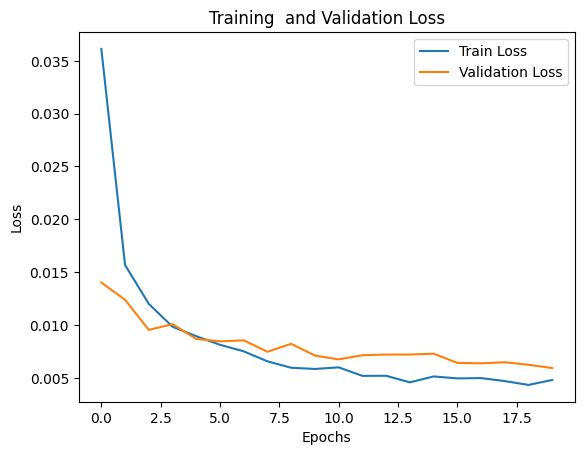

In [ ]:
class GNNModel1(nn.Module):
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, u_dim=U_DIM):
        super().__init__()
        # For the edges
        
        # self.edge_nn = nn.Sequential(nn.Linear(edge_dim, 64),nn.ReLU(),nn.Linear(64, node_dim * hidden_dim))

        # self.conv0 = NNConv(node_dim, hidden_dim, self.edge_nn, aggr='mean')
        self.conv0 = GATv2Conv(node_dim, hidden_dim, edge_dim=edge_dim)
        
        self.conv1 = CGConv(hidden_dim, edge_dim, aggr='mean') # , batch_norm=True)
        self.conv2 = CGConv(hidden_dim, edge_dim, aggr='mean') # , batch_norm=True)
        self.conv3 = CGConv(hidden_dim, edge_dim, aggr='mean') # , batch_norm=True)

        self.global_embed = nn.Linear(u_dim, embed_dim)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
        )

        x = F.relu(self.conv0(x, edge_index, edge_attr))
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.relu(self.conv3(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch)

        u = self.global_embed(u)

        x = torch.cat([x, u], dim=1)

        the_return = self.fc(x)
        return the_return


# PARAMETERIZE THE MODEL

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model1 = GNNModel1().to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
# loss_fn = LogCoshLoss()
loss_fn = RelativeWeightedLoss()
EPOCHS = 20

# TRAIN AND VALIDATE MODEL

train_losses = []
val_losses = []

for epoch in range(1, EPOCHS+1):
    t_loss = train(model1, train_loader, loss_fn, device, optimizer)
    train_losses.append(t_loss)

    v_loss = evaluate(model1, val_loader, loss_fn, device)
    val_losses.append(v_loss)

    scheduler.step()
    print(f'Epoch {epoch:03d}, Train Loss: {t_loss:.4f}, Val Loss: {v_loss:.4f}')

test_loss = evaluate(model1, test_loader, loss_fn, device)
print(f'Test Loss: {test_loss:.4f}')


# VISUALIZE METRICS

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training  and Validation Loss')
plt.legend()
plt.show()

/tmp/ipykernel_930590/3877983932.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()


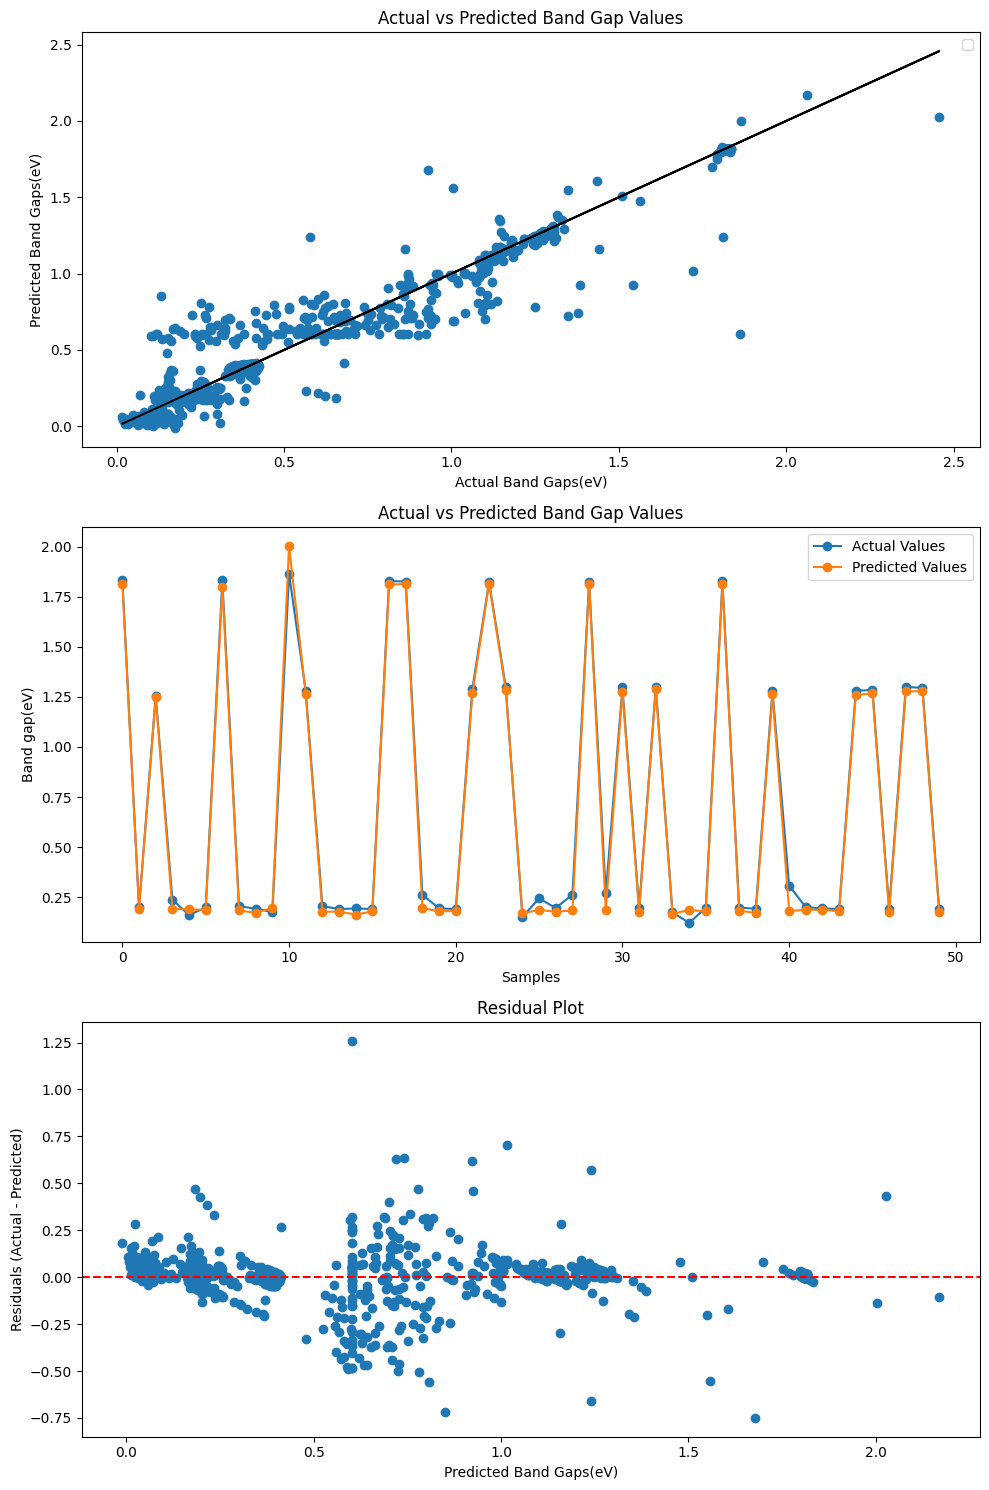

In [ ]:
# Make Predictions
predicted, the_target = predict(model1, test_loader,device, visualize=True)

# ERROR ANALYSIS

mae = mean_absolute_error(the_target, predicted)
mse = mean_squared_error(the_target, predicted)
r2 = r2_score(the_target, predicted)

print(f'Mean Absolute Error: {mae:.4f}')
print(f'Mean Squared Error: {mse:.4f}')
print(f'R-squared: {r2:.4f}')


In [15]:
# Save the model
path_file = "Final_Dataset/gnn models/GNNModel1.pth"
torch.save(model1.state_dict(), path_file)

## Model 2

In [ ]:
class GNNModel2(nn.Module):
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, u_dim=U_DIM):
        super().__init__()

        # For the edges
        self.edge_nn = nn.Sequential(
            nn.Linear(edge_dim, 64),
            nn.ReLU(),
            nn.Linear(64, node_dim * hidden_dim)
        )

        self.conv1 = NNConv(node_dim, hidden_dim, self.edge_nn, aggr='mean')

        # self.conv1 = CGConv(hidden_dim, hidden_dim, aggr='mean')
        self.conv2 = CGConv(hidden_dim, edge_dim, aggr='mean')

        self.global_embed = nn.Linear(u_dim, embed_dim)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
        )
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch)

        u = self.global_embed(u)

        x = torch.cat([x, u], dim=1)
        the_return = self.fc(x)
        return the_return


train_losses = []
val_losses = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model2 = GNNModel2().to(device)
optimizer = torch.optim.Adam(model2.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
loss_fn = LogCoshLoss()
EPOCHS = 20

for epoch in range(1, EPOCHS+1):
    t_loss = train(model2, train_loader, loss_fn, device, optimizer)
    train_losses.append(t_loss)

    v_loss = evaluate(model2, val_loader, loss_fn, device)
    val_losses.append(v_loss)

    scheduler.step()
    print(f'Epoch {epoch:03d}, Train Loss: {t_loss:.4f}, Val Loss: {v_loss:.4f}')

test_loss = evaluate(model2, test_loader, loss_fn, device)
print(f'Test Loss: {test_loss:.4f}')

# Visualize metrics
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training  and Validation Loss')
plt.legend()
plt.show()

In [ ]:
# Save the model
# path_file = "Final_Dataset/gnn models/GNNModel2.pth"
# torch.save(model2.state_dict(), path_file)

## Model 3

In [ ]:
class GNNModel3(nn.Module):
    def __init__(self, node_dim=NODE_DIM, edge_dim=EDGE_DIM, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM, global_dim=U_DIM):
        super().__init__()

        # Edge network for NNConv: maps each edge_attr to a weight matrix
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, node_dim * hidden_dim),
        )

        # First message-passing layer
        self.conv1 = NNConv(node_dim, hidden_dim, self.edge_mlp, aggr='mean')

        # Second message-passing layer using CGConv
        self.conv2 = CGConv(hidden_dim, edge_dim, aggr='mean')
        # self.conv3 = CGConv(hidden_dim, edge_dim, aggr='mean')

        # Embed the graph-level global features
        self.global_embed = nn.Linear(global_dim, embed_dim)

        # Final MLP head
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, 128),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.Dropout(0.2),
            # NO ReLU here - allow both positive and negative outputs
            nn.Linear(32, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch, u = (
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.u,
        )

        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        # x = F.relu(self.conv3(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch)
        u = self.global_embed(u)

        x = torch.cat([x, u], dim=1)
        return self.fc(x)


train_losses = []
val_losses = []

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model3 = GNNModel3().to(device)
optimizer = torch.optim.Adam(model3.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
loss_fn = LogCoshLoss()
EPOCHS = 20

for epoch in range(1, EPOCHS+1):
    t_loss = train(model3, train_loader, loss_fn, device, optimizer)
    train_losses.append(t_loss)

    v_loss = evaluate(model3, val_loader, loss_fn, device)
    val_losses.append(v_loss)

    scheduler.step()
    print(f'Epoch {epoch:03d}, Train Loss: {t_loss:.4f}, Val Loss: {v_loss:.4f}')

test_loss = evaluate(model3, test_loader, loss_fn, device)
print(f'Test Loss: {test_loss:.4f}')

# Visualize metrics
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training  and Validation Loss')
plt.legend()
plt.show()

In [ ]:
# Save the model
# path_file = "Final_Dataset/gnn models/GNNModel3.pth"
# torch.save(model3.state_dict(), path_file)